# Univariate LSTM model with limited input

**Directly predict *near-term* volatility (only) from historical return and volatility.**

Author: Pete King

This notebook uses financial data to train a univariate Long Short-Term Memory (LSTM) model to predict ***near-term*** **volatility** for a single ETF representing a market sector, using only the ETF's historical return and volatility as input.

The purpose of this notebook is to establish a baseline for an LSTM's ability to predict future volatility in a near-term outlook using limited input.  Subsequent LSTM models will incorporate additional features derived from macroeconomic data and market sentiment indicies.  We will compare performance of the models with limited vs. expanded input to asses the degree to which additional features help or hinder a model's ability to predict future financial performance.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)

import data_prep as dp
import models

# Global variables
DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_etf_data.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_etf_data.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 21  # No. observations in each input sequence to LSTM
BATCH_SIZE = 5  # For DataLoader

## I. Data Preparation

### Import and inspect financial data

We keep only return and historical volatility features for the asset in question.

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
data_cols = [TICKER + '_ret-h', TICKER + '_log_vol-h']
label_col = [TICKER + '_log_vol_target']
train_df[data_cols + label_col]

,SPY_ret-h,SPY_log_vol-h,SPY_log_vol_target
date,,,
2015-10-15,0.005650,-4.866436,-4.861645
2015-10-16,0.009590,-4.833447,-4.863256
2015-10-19,0.009138,-4.834473,-4.759188
2015-10-20,0.014181,-4.899117,-4.754619
2015-10-21,0.012764,-4.871746,-4.774913
...,...,...,...
2022-11-25,0.020313,-4.947791,-4.287979
2022-11-28,-0.000303,-4.615049,-4.302467
2022-11-29,0.001621,-4.625682,-4.287964


In [3]:
val_df[data_cols + label_col]

,SPY_ret-h,SPY_log_vol-h,SPY_log_vol_target
date,,,
2023-01-03,-0.005473,-4.590357,-4.515286
2023-01-04,0.006169,-4.549787,-4.517698
2023-01-05,0.007195,-4.572331,-4.436900
2023-01-06,0.012029,-4.416122,-4.591230
2023-01-09,0.014099,-4.420689,-4.590826
...,...,...,...
2024-08-26,0.002106,-5.078768,-4.605422
2024-08-27,0.005106,-5.080745,-4.556703
2024-08-28,-0.004147,-5.026514,-4.540425


## II. PyTorch Multivariate LSTM Model

In this section we use the PyTorch library to create Datasets and DataLoaders that we will use to introduce training samples to the LSTM model in batches.

We use a custom Dataset for time series data.  The Dataset implements a rolling window that captures a series of data points from time (t - L) to time (t - 1), where L is the size of the rolling window (i.e., sequence length).  Thus each data sample is a matrix with dimensions (num_features, L), where num_features is the number of features in each data instance.

Our goal is to predict future volatility, but what remains unknown is how far into the future we should try to predict.  In this investigation, we will vary the size of the future-looking window for volatility and examine the empirical results.

### Create Datasets and DataLoaders

For the initial investigation, we try to predict the *current day's volatility* using past observations.

*Note: PyTorch LSTM models require input to use datatype 'np.float32'*

In [4]:
X_train = train_df.dropna()[data_cols]
y_train = train_df.dropna()[label_col]
X_val = val_df.dropna()[data_cols]
y_val = val_df.dropna()[label_col]
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32).values,
    y_train.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32).values,
    y_val.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [5]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([21, 2])
Shape of first training label: torch.Size([1])


In [6]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([5, 21, 2])
Shape of first batch of labels: torch.Size([5, 1])


### Instantiate and train LSTM model

An important tunable hyperparameter for the LSTM is the size of the hidden layer.  A larger number of neurons will increase model complexity and could lead to overfitting, while too few neurons would increase the model's bias.  Considering the small number of input features, we use a relatively small hidden layer size.

Sequence length is another important hyperparameter.  We chose a sequence length of 21 to give our model one month (21 business days) worth of data, which should allow the model to learn recent trends in returns and volatility and perhaps learn relationships like, "several days of high returns leads to a period of high volatility," or "a spike in volatility tends to gradually decline over time towards the original baseline."

The ability of the LSTM to treat successive timestamps a dependent variables is a huge advantage over the Ridge and GBR models, which assume that all observations are independent of each other.

In [7]:
# Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 16  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [8]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [9]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(2, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)


#### Loss function and Optimizer

The loss function and optimizer represent other hyperparameters we can tune for the LSTM model.  In undocumented tests, we explored the mean squared error loss function (MSELoss) and the root mean squared propagation (RMSprop) optimizer, but found the best results with the combinations below.

In [10]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [11]:
# Train and evaluate model
epochs = 100
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
    all_preds.append(preds)
    if epochs <= 20:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')
    else:
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'Training loss:   {loss_trn}')
            print(f'Validation loss: {loss_val}')

Training model over 100 epochs...
Epoch 10
Training loss:   0.14810343086719513
Validation loss: 0.2429206371307373
Epoch 20
Training loss:   0.143384650349617
Validation loss: 0.09744668006896973
Epoch 30
Training loss:   0.18198451399803162
Validation loss: 0.03617215156555176
Epoch 40
Training loss:   0.18172988295555115
Validation loss: 0.03760218620300293
Epoch 50
Training loss:   0.18971118330955505
Validation loss: 0.04359292984008789
Epoch 60
Training loss:   0.12733039259910583
Validation loss: 0.05582475662231445
Epoch 70
Training loss:   0.15241841971874237
Validation loss: 0.08485150337219238
Epoch 80
Training loss:   0.15230302512645721
Validation loss: 0.10576796531677246
Epoch 90
Training loss:   0.14174088835716248
Validation loss: 0.07651185989379883
Epoch 100
Training loss:   0.13733787834644318
Validation loss: 0.08603882789611816


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


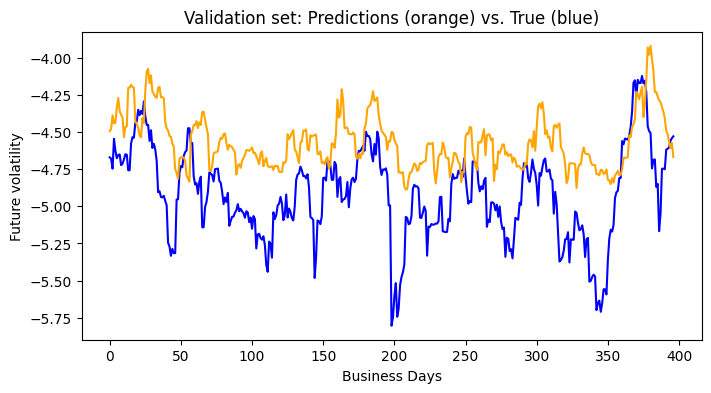

In [12]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. True (blue)')
ax.set_ylabel('Future volatility')
ax.set_xlabel('Business Days')
ax.plot(x, labels, color='blue')
ax.plot(x, preds, color='orange')

These results look promising!  Starting to believe we are on the right track with predicting volatility.  Even though the model consistently predicts a higher volatility value, the predictions tend to go in the right direction: when true market volatility is increasing, our model also predicts an increase in volatility.  With some tuning we may be able to improve results.

In [13]:
metrics = {
    'R2': r2_score,
    'MAE': mean_absolute_error,
    'RMSE': root_mean_squared_error,
    'MSE': mean_squared_error
}
for metric, scorer in metrics.items():
    print(metric + f': {scorer(labels, np.asarray(preds))}')

R2: -1.095062255859375
MAE: 0.37266770005226135
RMSE: 0.44321832060813904
MSE: 0.19644246995449066


With the LSTM, instead of seeing a temporal lag as we did with the Ridge and GBR models, we see a puzzling bias towards higher volatility.  This bias negatively effects our MAE and R-squared values.

Let's see what happens to our model's scores if we manually correct for the observed bias in the model by simply subtracing a constant value.

In [14]:
# The model seems to consistently overestimate future volatility. We test
# the effect of subtracting a constant value from all predictions 
# to remove bias and better align predictions with labels
for metric, scorer in metrics.items():
    print(metric + f': {scorer(labels, np.asarray(preds) - 0.0034)}')

R2: -1.0697588920593262
MAE: 0.36995983123779297
RMSE: 0.44053366780281067
MSE: 0.19406992197036743


When we correct for the model's consistent bias towards higher volatility values, our R-squared value looks amazing, and the plot of predictions vs. labls also lines up very nicely.

Not sure where the bias would be coming from, other than possibly the small sample size in the historical volatility feature computation (WINDOW_SIZE = 10 days), compared to the longer future volatility outlook (21 days).

A plot of bias-corrected predictions appears below.

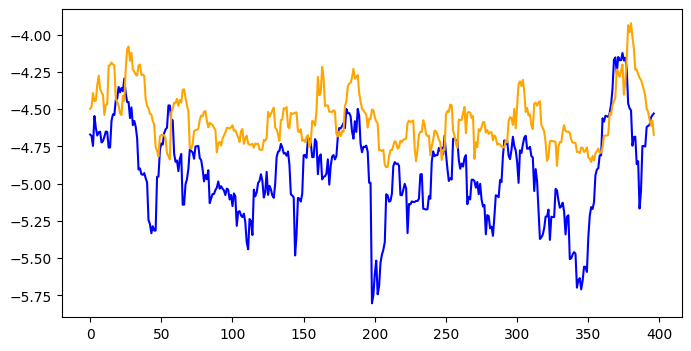

In [15]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()

ax.plot(x, labels, color='blue')
ax.plot(x, np.asarray(preds - 0.0034), color='orange')

After investigating a wide variety of models with varying inputs, the LSTM with limited input provides the most consistent results where the model predicts an increasing trend in sync with an actual increasing trend in volatility.  Going forward with this model, a final step will be to find a robust method for correcting the model's bias.  A naive approach would be to simply test a range of bias-correcting values and select the one that produces the highest R-squared value.